# Fase 1 - Predicción de cancelación de reservas hoteleras

Este proyecto busca construir un modelo de clasificación capaz de predecir si una reserva hotelera será cancelada.

La variable objetivo es `is_canceled`, donde el valor `1` representa una reserva cancelada y el valor `0` representa una reserva no cancelada.

El problema se aborda como una clasificación binaria. La fuente de datos corresponde al conjunto de datos Hotel Booking Demand, previamente aprobado para el desarrollo del proyecto.

## Importación de librerías y configuración

Librerías necesarias para cargar, explorar, visualizar y preparar los datos. Se define una semilla aleatoria para que los resultados obtenidos puedan reproducirse.



In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

RANDOM_STATE = 42

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

print("Versión de pandas:", pd.__version__)
print("Versión de scikit-learn:", sklearn.__version__)

Versión de pandas: 2.2.3
Versión de scikit-learn: 1.6.1


## Carga del conjunto de datos

El archivo `hotel_bookings.csv` se obtiene automáticamente desde una versión específica del repositorio público. Esto permite ejecutar el notebook desde el inicio en Colab sin subir el CSV manualmente y mantiene constante el conjunto de datos utilizado en el experimento.

In [15]:
URL_DATOS = (
    "https://raw.githubusercontent.com/CristianAlvarez00/Modelo-hotel/"
    "65ee039efe2bc8e67ed399ae1cbb0308aa447e1c/"
    "data/hotel_bookings.csv"
)

df = pd.read_csv(URL_DATOS)

assert df.shape == (119390, 32), "El CSV no tiene las dimensiones esperadas."

print("Datos cargados desde el repositorio de GitHub")
print(f"Dimensiones del dataset: {df.shape[0]} filas y {df.shape[1]} columnas")
display(df.head())

Datos cargados desde el repositorio de GitHub
Dimensiones del dataset: 119390 filas y 32 columnas


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## Descripción general del conjunto de datos

En esta sección se revisan las dimensiones, los tipos de datos y algunos ejemplos del conjunto de datos. Esto permite identificar variables numéricas, categóricas y de fecha, además de detectar posibles problemas que deben tratarse antes del entrenamiento.

In [16]:
print("Información general del dataset:")
df.info()

print("\nTipos de datos por columna:")
display(df.dtypes.to_frame(name="tipo_de_dato"))

Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-nu

,tipo_de_dato
hotel,object
is_canceled,int64
lead_time,int64
arrival_date_year,int64
arrival_date_month,object
arrival_date_week_number,int64
arrival_date_day_of_month,int64
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64


## Valores faltantes y registros duplicados

Los valores faltantes pueden afectar el entrenamiento de los modelos, por lo cual se cuantifican antes de tomar decisiones de limpieza. También se revisan los registros duplicados, debido a que pueden alterar el análisis y generar resultados demasiado optimistas si aparecen tanto en entrenamiento como en prueba.

In [17]:
resumen_calidad = pd.DataFrame({
    "valores_faltantes": df.isnull().sum(),
    "porcentaje_faltantes": (df.isnull().mean() * 100).round(2),
    "valores_unicos": df.nunique(),
    "tipo_de_dato": df.dtypes
}).sort_values("porcentaje_faltantes", ascending=False)

display(resumen_calidad)

duplicados = df.duplicated().sum()

print(f"Registros duplicados exactos: {duplicados}")
print(f"Porcentaje de registros duplicados: {(duplicados / len(df) * 100):.2f}%")

,valores_faltantes,porcentaje_faltantes,valores_unicos,tipo_de_dato
company,112593,94.31,352,float64
agent,16340,13.69,333,float64
country,488,0.41,177,object
hotel,0,0.00,2,object
arrival_date_month,0,0.00,12,object
arrival_date_week_number,0,0.00,53,int64
lead_time,0,0.00,479,int64
is_canceled,0,0.00,2,int64
stays_in_weekend_nights,0,0.00,17,int64
stays_in_week_nights,0,0.00,35,int64


Registros duplicados exactos: 31994
Porcentaje de registros duplicados: 26.80%


Podemos observar que algunas variables, como company, tienen cerca del **95% de sus valores faltantes**. En el tratamiento de los datos es necesario tomar medidas, sea imputar con base al 5% de registros que sí tienen el campo company asignado, o bien sea eliminar la columna. **Agent** es la segunda característica con mayor cantidad de faltantes, con un 13%. En el tratamiento de datos decidiremos qué se hará al respecto con este par de características.
También podemos observar que tenemos una **cuarta parte** del total de registros "duplicados". Lo pongo entre comillas porque a través del método .duplicated() no es posible garantizar que efectivamente son registros duplicados. En el tratamiento de datos decidiremos qué hacer con ello.

## Estadísticas descriptivas

A continuación se resumen algunas variables numéricas relacionadas con la anticipación de la reserva, la duración de la estancia, el número de huéspedes y el precio. Se revisan también variables categóricas para conocer sus valores más frecuentes. Los valores extremos se identifican, pero los modificamos en la próxima sección.

In [18]:
columnas_numericas = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "adr"
]

display(df[columnas_numericas].describe().round(2))

columnas_categoricas = [
    "hotel",
    "meal",
    "market_segment",
    "deposit_type",
    "customer_type"
]

display(df[columnas_categoricas].describe().T)

,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,adr
count,119390.00,119390.00,119390.00,119390.00,119386.0,119390.00,119390.00
mean,104.01,0.93,2.50,1.86,0.1,0.01,101.83
std,106.86,1.00,1.91,0.58,0.4,0.10,50.54
min,0.00,0.00,0.00,0.00,0.0,0.00,-6.38
25%,18.00,0.00,1.00,2.00,0.0,0.00,69.29
50%,69.00,1.00,2.00,2.00,0.0,0.00,94.58
75%,160.00,2.00,3.00,2.00,0.0,0.00,126.00
max,737.00,19.00,50.00,55.00,10.0,10.00,5400.00


,count,unique,top,freq
hotel,119390,2,City Hotel,79330
meal,119390,5,BB,92310
market_segment,119390,8,Online TA,56477
deposit_type,119390,3,No Deposit,104641
customer_type,119390,4,Transient,89613


## Distribución de la variable objetivo

La variable `is_canceled` indica si una reserva fue cancelada. Se analiza su distribución para conocer la proporción de cada clase y determinar si existe un desbalance que pueda afectar la evaluación de los modelos.

,cantidad,porcentaje
is_canceled,,
No cancelada,75166,62.96
Cancelada,44224,37.04


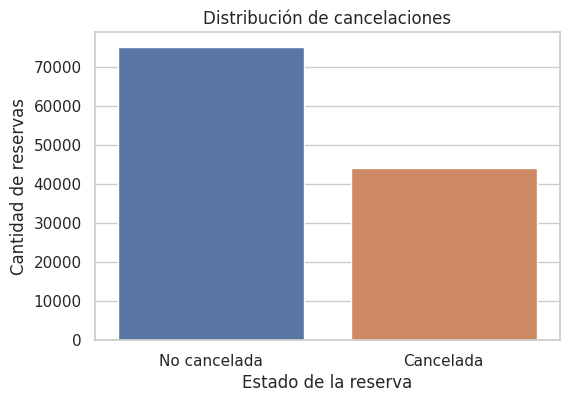

In [19]:
distribucion_objetivo = (
    df["is_canceled"]
    .value_counts()
    .rename(index={0: "No cancelada", 1: "Cancelada"})
    .to_frame(name="cantidad")
)

distribucion_objetivo["porcentaje"] = (
    distribucion_objetivo["cantidad"] / len(df) * 100
).round(2)

display(distribucion_objetivo)

plt.figure(figsize=(6, 4))
sns.countplot(
    data=df,
    x="is_canceled",
    hue="is_canceled",
    palette=["#4C72B0", "#DD8452"],
    legend=False
)
plt.xticks([0, 1], ["No cancelada", "Cancelada"])
plt.xlabel("Estado de la reserva")
plt.ylabel("Cantidad de reservas")
plt.title("Distribución de cancelaciones")
plt.show()

Es posible observar un desbalanceo apreciable **(62% contra 37%)**.

## Relación entre características de la reserva y cancelación

Se compara la proporción de reservas canceladas entre tipos de hotel, tipos de depósito y rangos de anticipación. Estas comparaciones permiten identificar patrones iniciales, pero no demuestran que una variable cause la cancelación.

In [20]:
for columna in ["hotel", "deposit_type"]:
    resumen = df.groupby(columna)["is_canceled"].agg(
        reservas="count",
        porcentaje_canceladas=lambda valores: round(valores.mean() * 100, 2)
    )
    print(f"\nCancelaciones según {columna}:")
    display(resumen)

rangos_anticipacion = pd.cut(
    df["lead_time"],
    bins=[-1, 7, 30, 90, 180, float("inf")],
    labels=["0-7", "8-30", "31-90", "91-180", "Más de 180"]
)

resumen_anticipacion = (
    df.assign(rango_anticipacion=rangos_anticipacion)
      .groupby("rango_anticipacion", observed=True)["is_canceled"]
      .agg(
          reservas="count",
          porcentaje_canceladas=lambda valores: round(valores.mean() * 100, 2)
      )
)

display(resumen_anticipacion)


Cancelaciones según hotel:


,reservas,porcentaje_canceladas
hotel,,
City Hotel,79330,41.73
Resort Hotel,40060,27.76



Cancelaciones según deposit_type:


,reservas,porcentaje_canceladas
deposit_type,,
No Deposit,104641,28.38
Non Refund,14587,99.36
Refundable,162,22.22


,reservas,porcentaje_canceladas
rango_anticipacion,,
0-7,19746,9.63
8-30,18960,27.86
31-90,29553,37.70
91-180,26439,44.71
Más de 180,24692,57.01


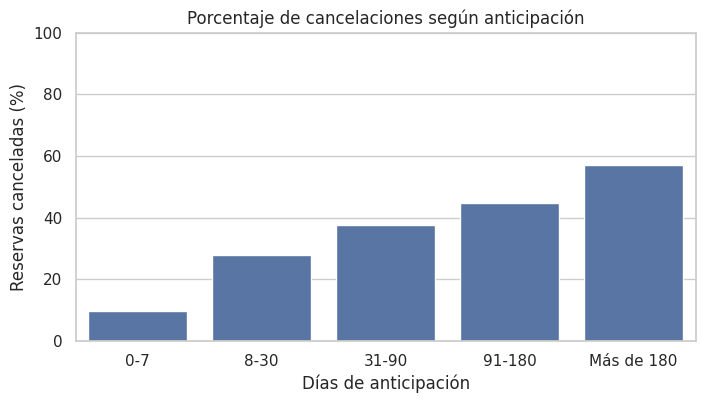

In [21]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=resumen_anticipacion.reset_index(),
    x="rango_anticipacion",
    y="porcentaje_canceladas",
    color="#4C72B0"
)
plt.xlabel("Días de anticipación")
plt.ylabel("Reservas canceladas (%)")
plt.title("Porcentaje de cancelaciones según anticipación")
plt.ylim(0, 100)
plt.show()

## Correlación entre variables numéricas

Se calcula la correlación de Pearson entre variables numéricas que representan cantidades o medidas. Se excluyen identificadores como `agent` y `company`, porque sus números funcionan como códigos y no como magnitudes. También se excluye `is_canceled` de esta matriz, ya que el propósito de esta sección es revisar posibles redundancias entre variables predictoras.

Una correlación alta podría indicar que dos variables aportan información similar. No se eliminará ninguna variable únicamente por este resultado; cualquier decisión se justificará durante la preparación de los datos.

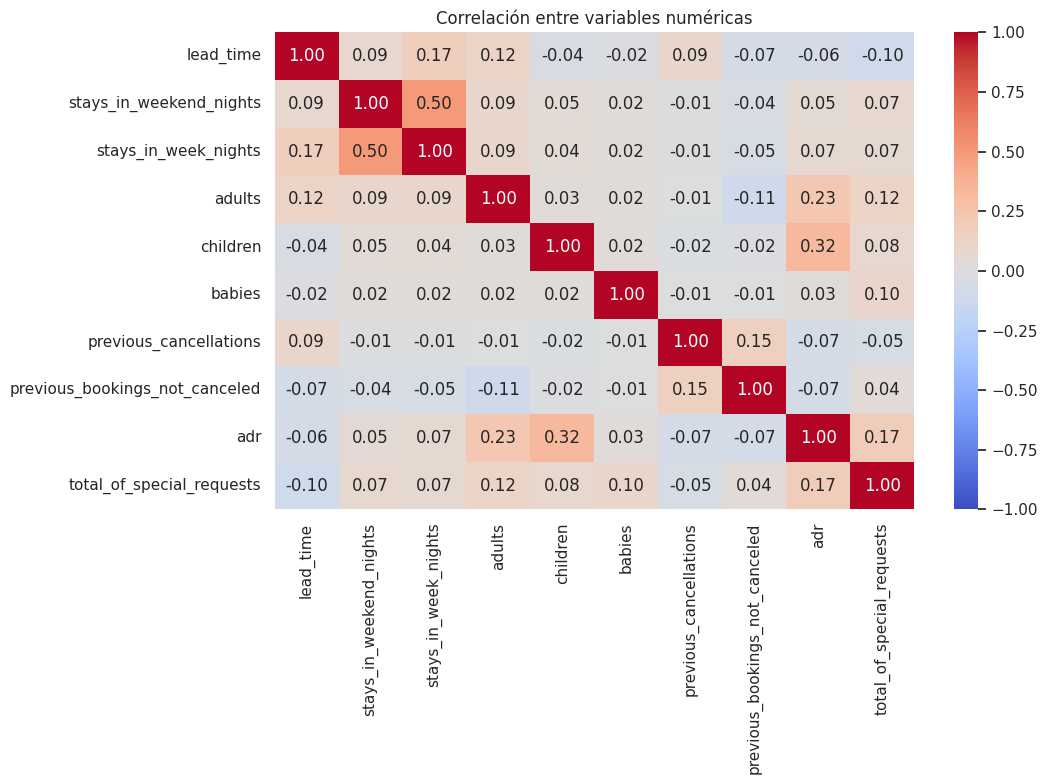

In [22]:
variables_correlacion = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "adr",
    "total_of_special_requests"
]

correlaciones = df[variables_correlacion].corr(method="pearson")

plt.figure(figsize=(11, 8))
sns.heatmap(
    correlaciones,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)
plt.title("Correlación entre variables numéricas")
plt.tight_layout()
plt.show()

Es posible notar que la correlación entra las variables es relativamente baja en su mayoría. La correlación más grande que se presenta dentro de la matriz es entre **Reservas en noche en semana**, y **Reservas en noches en fin de semana**, lo cual es esperable. Evaluaremos en la próxima sección si es posible eliminar una de las columnas, es decir, con una es lo suficientemente descriptivo para el aprendizaje del modelo, o si resulta mejor incluirlas ambas.

## Preparación de los datos

El modelo intentará predecir la cancelación con características que puedan conocerse al registrar una reserva. Por ello se seleccionan variables sobre el hotel, la estancia prevista, los huéspedes, el canal de reserva y el historial previo del cliente.

No se eliminan observaciones en esta etapa. Aunque existen filas idénticas, no hay un identificador de reserva que permita afirmar que corresponden a duplicados reales. Además, eliminarlas modifica considerablemente la proporción de cancelaciones. Durante la separación de entrenamiento y prueba se evitará que filas con las mismas características seleccionadas aparezcan en ambos conjuntos.

Se excluyen `reservation_status` y `reservation_status_date` porque describen el resultado de la reserva. También se excluyen `assigned_room_type`, `booking_changes` y `days_in_waiting_list`, que pueden incorporar información posterior a su registro. Para esta primera implementación se excluyen `deposit_type` y `adr`: en la descripción original del dataset se indica que pueden calcularse con pagos o transacciones registrados después de crear la reserva. Su uso podría producir una evaluación demasiado optimista.

Se excluyen `agent` y `company`, por su gran proporción de nulos. Sus números son identificadores, no cantidades. La fuente original indica además que algunos de sus valores `NULL` significan que el campo no aplica. Se conservan las noches entre semana y en fin de semana porque describen aspectos distintos de la estancia; más adelante podrá compararse una implementación con menos variables.

In [23]:
columnas_numericas_modelo = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "is_repeated_guest",
    "previous_cancellations",
    "previous_bookings_not_canceled"
]

columnas_categoricas_modelo = [
    "hotel",
    "arrival_date_month",
    "meal",
    "country",
    "market_segment",
    "distribution_channel",
    "reserved_room_type",
    "customer_type"
]

columnas_modelo = columnas_numericas_modelo + columnas_categoricas_modelo

X = df[columnas_modelo].copy()
y = df["is_canceled"].copy()

print(f"Observaciones conservadas: {len(X)}")
print(f"Variables predictoras seleccionadas: {X.shape[1]}")
print("Variable objetivo:", y.name)

print("\nValores faltantes en las variables seleccionadas:")
display(X.isna().sum()[X.isna().sum() > 0].to_frame("cantidad"))

Observaciones conservadas: 119390
Variables predictoras seleccionadas: 17
Variable objetivo: is_canceled

Valores faltantes en las variables seleccionadas:


,cantidad
children,4
country,488


### Tratamiento de valores faltantes y codificación

`children` tiene cuatro valores faltantes. Se reemplazarán por la mediana calculada únicamente con el conjunto de entrenamiento. Se elige la mediana porque es una medida sencilla y menos afectada por valores extremos que el promedio.

Los 488 valores faltantes de `country` se representarán con la categoría `Desconocido`. Esto permite conservar las observaciones sin atribuirles un país que no conocemos.

Las variables categóricas se codificarán mediante one-hot encoding, creando indicadores numéricos para sus categorías. Las variables numéricas se escalarán para que sus diferentes unidades no afecten desproporcionadamente a modelos como la regresión logística. Estas transformaciones se ajustarán solo con entrenamiento y después se aplicarán a prueba.

Por ahora no se eliminan ni transforman valores extremos. Se revisará su efecto al comparar las implementaciones de los modelos.

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preparacion_numerica = Pipeline(steps=[
    ("imputar", SimpleImputer(strategy="median")),
    ("escalar", StandardScaler())
])

preparacion_categorica = Pipeline(steps=[
    ("imputar", SimpleImputer(
        strategy="constant",
        fill_value="Desconocido"
    )),
    ("codificar", OneHotEncoder(handle_unknown="ignore"))
])

preprocesador = ColumnTransformer(transformers=[
    ("numericas", preparacion_numerica, columnas_numericas_modelo),
    ("categoricas", preparacion_categorica, columnas_categoricas_modelo)
])

print("Transformaciones definidas. Todavía no se han ajustado con los datos.")

Transformaciones definidas. Todavía no se han ajustado con los datos.


## Separación de entrenamiento y prueba

Se reserva aproximadamente el 20% de los datos para prueba y el resto para entrenamiento. Se utiliza una semilla fija para que la separación pueda reproducirse.

No se eliminaron las filas idénticas, ya que no se puede confirmar que correspondan a la misma reserva. En cambio, las filas que tienen exactamente las mismas características seleccionadas se asignan al mismo conjunto. Así se evita que una copia de las entradas del modelo aparezca simultáneamente en entrenamiento y prueba, de manera que podamos evitar entregar en los datos de prueba elementos usados en el entrenamiento, y que así no altere las métricas del modelo.

La separación se realiza antes de ajustar la imputación, el escalamiento o la codificación. El conjunto de prueba se conservará sin usar durante la comparación y selección de modelos.

In [25]:
from sklearn.model_selection import GroupShuffleSplit

# Filas con las mismas características reciben el mismo identificador de grupo.
grupos = pd.util.hash_pandas_object(X, index=False)

separador = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

indices_entrenamiento, indices_prueba = next(
    separador.split(X, y, groups=grupos)
)

X_train = X.iloc[indices_entrenamiento].copy()
X_test = X.iloc[indices_prueba].copy()

y_train = y.iloc[indices_entrenamiento].copy()
y_test = y.iloc[indices_prueba].copy()

print(f"Filas de entrenamiento: {len(X_train)} ({len(X_train) / len(X):.2%})")
print(f"Filas de prueba: {len(X_test)} ({len(X_test) / len(X):.2%})")

print(f"Cancelaciones en entrenamiento: {y_train.mean():.2%}")
print(f"Cancelaciones en prueba: {y_test.mean():.2%}")

Filas de entrenamiento: 95003 (79.57%)
Filas de prueba: 24387 (20.43%)
Cancelaciones en entrenamiento: 37.30%
Cancelaciones en prueba: 36.04%


## Verificación de la separación y prevención de fuga de información

En esta celda se verifica que los conjuntos no compartan índices ni grupos de características idénticas. La variable objetivo no forma parte de `X`. También se comprueba que los valores faltantes permanezcan sin imputar: el preprocesamiento se ajustará más adelante únicamente con el conjunto de entrenamiento.

Las columnas que describen el estado final de la reserva o que pueden contener información posterior no se incluyen entre las variables predictoras.

In [26]:
grupos_train = set(grupos.iloc[indices_entrenamiento])
grupos_test = set(grupos.iloc[indices_prueba])

assert set(X_train.index).isdisjoint(X_test.index)
assert grupos_train.isdisjoint(grupos_test)
assert "is_canceled" not in X_train.columns

columnas_excluidas_por_fuga = [
    "reservation_status",
    "reservation_status_date",
    "assigned_room_type",
    "booking_changes",
    "days_in_waiting_list",
    "deposit_type",
    "adr"
]

assert not set(columnas_excluidas_por_fuga).intersection(X_train.columns)

print("La separación no comparte filas ni grupos de entradas idénticas.")
print("La variable objetivo y las columnas excluidas no están en X_train.")

print("\nValores faltantes pendientes de tratamiento en entrenamiento:")
display(X_train.isna().sum()[X_train.isna().sum() > 0].to_frame("cantidad"))

La separación no comparte filas ni grupos de entradas idénticas.
La variable objetivo y las columnas excluidas no están en X_train.

Valores faltantes pendientes de tratamiento en entrenamiento:


,cantidad
children,3
country,390
